# 03 — Управление позицией: что реально улучшает стратегию

Берём **лучшие стратегии этапа 02** и измеряем влияние механик управления позицией:

Stop Loss · Take Profit · Trailing Stop · Break Even · Time Stop ·
Exit on Opposite Signal · частичная фиксация прибыли · комбинации.

**Методология честной оценки.** Для каждой пары (стратегия, механика):

1. параметры механики оптимизируются **только на in-sample** (70% истории);
2. лучшая IS-конфигурация сравнивается с **baseline той же стратегии**
   (выход только по противоположному сигналу) на **out-of-sample**;
3. вердикт: *real improvement* — лучше baseline и IS, и OOS;
   *false improvement* — лучше IS, но хуже OOS (классический оверфит выходов);
   *no effect / worse* — не помогает даже in-sample.

**Модель исполнения** (единый numba-симулятор → `Portfolio.from_orders`):
вход по close сигнального бара; стопы проверяются по OHLC внутри бара и
исполняются по цене стопа (при гэпе — по open); trailing использует пик
*предыдущих* баров; при касании стопа и тейка в одном баре консервативно
исполняется стоп; time stop и сигнальные выходы — по close. Частичная
фиксация закрывает долю позиции по своему уровню один раз за сделку.

Сравниваемые метрики: **CAGR, Profit Factor, Max Drawdown, Expectancy,
Recovery Factor, Sharpe, Calmar**.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import vectorbt as vbt
from plotly.subplots import make_subplots

from src.backtesting import BacktestConfig, ExitRules, exit_reason_counts, managed_portfolio
from src.data import load_data
from src.optimization import (
    COMPARE_METRICS,
    exit_research,
    mechanic_scoreboard,
    mechanic_universe,
    research_universe,
    summarize_mechanics,
    summarize_strategies,
)
from src.strategies import get_strategy
from src.utils.paths import RESULTS_DIR
from src.visualization import setup_github_rendering, show

setup_github_rendering()
pd.set_option("display.width", 220)
print("vectorbt:", vbt.__version__)

vectorbt: 1.0.0


## 1. Данные и лучшие стратегии этапа 02

Пересчитываем research-прогон для шести лидеров прошлого этапа и берём их
**репрезентативные параметры** (лучшие по robust score, не по доходности).

In [2]:
SYMBOL = "AAPL"
try:
    data = load_data("yahoo", SYMBOL, start="2018-01-01", end="2025-06-30")
    print("Данные получены из Yahoo Finance")
except Exception as exc:
    print(f"Yahoo Finance недоступен ({type(exc).__name__}), используем локальный CSV")
    SYMBOL = "SAMPLE"
    data = load_data("csv", SYMBOL)

ohlcv = data.get(SYMBOL)
print(f"{SYMBOL}: {len(ohlcv)} баров {ohlcv.index[0].date()}..{ohlcv.index[-1].date()}")

2026-07-04 12:39:55,501 | INFO    | src.data.yahoo_loader | Downloading AAPL from Yahoo Finance (1d, 2018-01-01..2025-06-30)


Failed to get ticker 'AAPL' reason: Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.



1 Failed download:


['AAPL']: ProxyError('Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Yahoo Finance недоступен (ValueError), используем локальный CSV
SAMPLE: 2000 баров 2018-01-01..2025-08-29


In [3]:
TOP_STRATEGIES = ["ema_rsi", "roc_momentum", "ichimoku", "supertrend", "triple_ema", "ema_adx"]

combined = research_universe(TOP_STRATEGIES, ohlcv, show_progress=True)
research_summary = summarize_strategies(combined)
best_params = {name: research_summary.loc[name, "best_params"] for name in TOP_STRATEGIES}

pd.DataFrame(
    {"params": best_params,
     "robust_score": research_summary.loc[TOP_STRATEGIES, "robust_score"].round(3)}
)

strategies:   0%|          | 0/6 [00:00<?, ?it/s]

,params,robust_score
ema_rsi,"{'fast_window': 20, 'slow_window': 200, 'pullb...",0.692
roc_momentum,"{'window': 20, 'threshold': 0.0}",0.614
ichimoku,"{'tenkan_window': 12, 'kijun_window': 26, 'sen...",0.530
supertrend,"{'window': 14, 'multiplier': 1.5}",0.331
triple_ema,"{'fast_window': 8, 'slow_window': 100, 'mid_wi...",0.313
ema_adx,"{'fast_window': 10, 'slow_window': 50, 'adx_wi...",0.489


## 2. Вселенная механик

Каждая механика оптимизируется по собственной сетке; отдельно тестируется
замена сигнальных выходов чистым trailing-стопом и четыре комбинации.

In [4]:
universe = mechanic_universe()
pd.DataFrame(
    [(m, len(rules), ", ".join(r.label for r in rules[:4]) + (" ..." if len(rules) > 4 else ""))
     for m, rules in universe.items()],
    columns=["mechanic", "configs", "examples"],
).set_index("mechanic")

,configs,examples
mechanic,,
baseline,1,baseline
stop_loss,5,"sl=0.03, sl=0.05, sl=0.08, sl=0.12 ..."
take_profit,5,"tp=0.05, tp=0.08, tp=0.12, tp=0.2 ..."
trailing_stop,5,"trail=0.04, trail=0.06, trail=0.1, trail=0.15 ..."
break_even,8,"be=0.03/0.0, be=0.03/0.01, be=0.05/0.0, be=0.0..."
time_stop,5,"time=5, time=10, time=20, time=40 ..."
trail_replaces_signal,5,"trail_only=0.04, trail_only=0.06, trail_only=0..."
partial_tp,6,"partial=0.05x0.3333333333333333, partial=0.05x..."
combo_sl_tp,8,"sl=0.05,tp=0.12, sl=0.05,tp=0.2, sl=0.05,tp=0...."


### Как работает симулятор: пример с причинами выходов

Supertrend + SL 8% + TP 20% + частичная фиксация половины на +8%:
каждый выход помечен причиной, поэтому вклад механик можно атрибуцировать.

Причины выходов (demo):
exit_reason
signal         34
partial_tp     17
take_profit     4


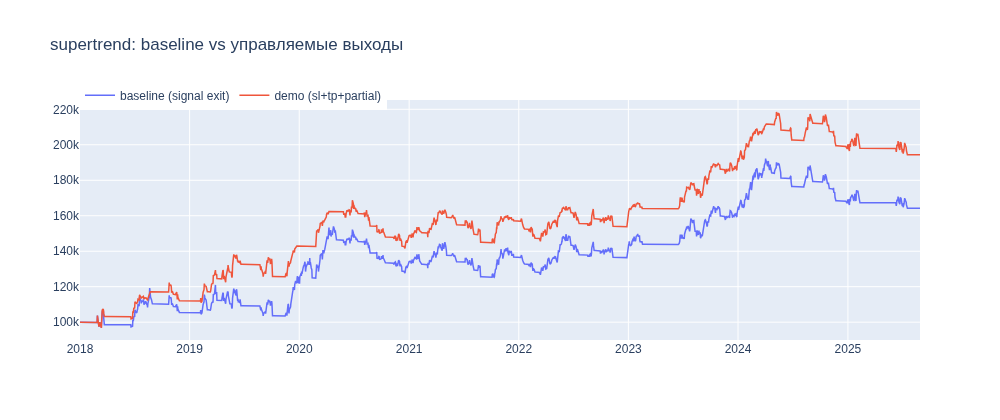

In [5]:
demo_rules = ExitRules(label="demo", sl_stop=0.08, tp_stop=0.20, partial_tp=0.08, partial_fraction=0.5)
sig = get_strategy("supertrend", **best_params["supertrend"]).signals(ohlcv)

pf_demo, reasons = managed_portfolio(ohlcv, sig.entries, sig.exits, demo_rules)
pf_base, _ = managed_portfolio(ohlcv, sig.entries, sig.exits, ExitRules())

print("Причины выходов (demo):")
print(exit_reason_counts(reasons).to_string())

fig = go.Figure()
fig.add_trace(go.Scatter(x=pf_base.value().index, y=pf_base.value(), name="baseline (signal exit)", line=dict(width=1.5)))
fig.add_trace(go.Scatter(x=pf_demo.value().index, y=pf_demo.value(), name=demo_rules.label + " (sl+tp+partial)", line=dict(width=1.5)))
fig.update_layout(title="supertrend: baseline vs управляемые выходы", width=1000, height=420,
                  legend=dict(orientation="h", y=1.08))
show(fig)

## 3. Массовый прогон: все стратегии × все механики × сетки параметров

~440 конфигураций, каждая бэктестится на IS- и OOS-окнах.

In [6]:
config = BacktestConfig()
SPLIT = 0.7

sweep = exit_research(best_params, ohlcv, universe, config=config, split=SPLIT, show_progress=True)

out_dir = RESULTS_DIR / "position_management"
out_dir.mkdir(parents=True, exist_ok=True)
sweep.to_csv(out_dir / "exit_rules_sweep.csv", index=False)
print(f"Готово: {len(sweep)} конфигураций для {sweep.strategy.nunique()} стратегий")

strategies:   0%|          | 0/6 [00:00<?, ?it/s]

Готово: 444 конфигураций для 6 стратегий


## 4. Сравнительные таблицы

Для каждой пары (стратегия, механика): конфигурация выбрана по лучшему
**IS Sharpe**, дельты приведены против baseline этой же стратегии.
`d_is_*` — изменение in-sample, `d_oos_*` — out-of-sample
(для Max Drawdown отрицательная дельта = просадка уменьшилась).

In [7]:
mech_summary = summarize_mechanics(sweep)
mech_summary.to_csv(out_dir / "mechanics_summary.csv", index=False)

delta_cols = [f"d_oos_{m}" for m in COMPARE_METRICS]
table = mech_summary[["strategy", "mechanic", "best_label", "verdict"] + delta_cols]
table.round(3)

,strategy,mechanic,best_label,verdict,d_oos_cagr_pct,d_oos_profit_factor,d_oos_max_drawdown_pct,d_oos_expectancy,d_oos_recovery_factor,d_oos_sharpe_ratio,d_oos_calmar_ratio
0,ema_adx,break_even,be=0.12/0.0,no effect / worse,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,ema_adx,combo_sl_tp,"sl=0.12,tp=0.3",false improvement,-3.438,-0.818,-0.923,-1550.930,-0.381,-0.045,-0.204
2,ema_adx,combo_sl_tp_time,"sl=0.08,tp=0.2,time=40",no effect / worse,-17.788,-5.065,-0.923,-7697.784,-3.171,-1.364,-1.832
3,ema_adx,combo_sl_trail_be,"sl=0.12,trail=0.15,be=0.05",oos-only (lucky),0.363,0.714,-0.460,165.577,0.224,0.073,0.127
4,ema_adx,combo_trail_partial,"trail=0.15,partial=0.08",no effect / worse,-7.612,-1.903,-0.923,-4213.896,-1.218,-0.295,-0.678
...,...,...,...,...,...,...,...,...,...,...,...
61,triple_ema,stop_loss,sl=0.05,false improvement,0.000,0.000,0.000,0.000,0.000,0.000,0.000
62,triple_ema,take_profit,tp=0.12,real improvement,0.546,0.075,0.000,157.768,0.073,0.214,0.042
63,triple_ema,time_stop,time=40,false improvement,-4.937,-0.727,-0.000,-1403.056,-0.653,-0.344,-0.383
64,triple_ema,trail_replaces_signal,trail_only=0.15,false improvement,3.128,inf,0.957,17149.101,0.319,-0.017,0.181


In [8]:
# Средний OOS-эффект механики по всем стратегиям (дельты против baseline)
pivot_effect = mech_summary.pivot_table(index="mechanic", values=delta_cols, aggfunc="mean")
pivot_effect.columns = [c.replace("d_oos_", "Δ ") for c in pivot_effect.columns]
pivot_effect.round(3).sort_values("Δ sharpe_ratio", ascending=False)

,Δ cagr_pct,Δ calmar_ratio,Δ expectancy,Δ max_drawdown_pct,Δ profit_factor,Δ recovery_factor,Δ sharpe_ratio
mechanic,,,,,,,
take_profit,0.536,0.254,-110.089,-1.385,-0.079,0.435,0.185
partial_tp,-0.591,0.135,-967.569,-1.290,-0.058,0.226,0.091
combo_trail_partial,-1.519,0.061,-1247.190,-1.632,-0.242,0.097,0.036
combo_sl_trail_be,0.106,0.027,35.558,-0.136,0.129,0.047,0.015
combo_sl_tp,-0.826,-0.046,-291.407,-0.307,-0.158,-0.084,0.011
stop_loss,0.000,0.000,0.000,0.000,0.000,0.000,0.000
trailing_stop,0.000,0.000,0.000,0.000,0.000,0.000,0.000
break_even,-1.731,-0.263,-233.513,0.739,-0.324,-0.453,-0.123
trail_replaces_signal,-0.044,-0.416,12024.122,5.518,inf,-0.714,-0.191


## 5. Тепловые карты эффективности

### Стратегия × механика: изменение OOS Sharpe и OOS Max Drawdown

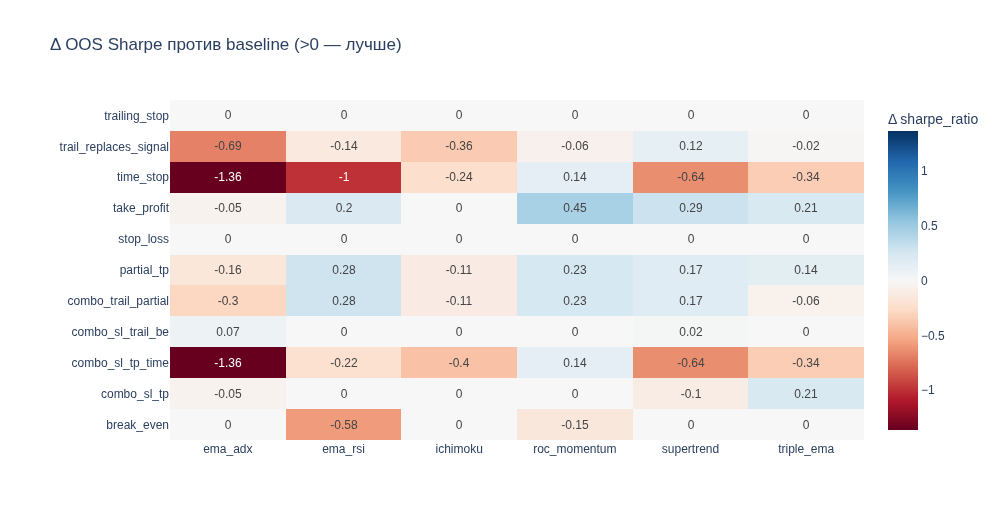

In [9]:
def strategy_mechanic_heatmap(metric: str, title: str, reverse: bool = False):
    grid = mech_summary.pivot_table(index="mechanic", columns="strategy", values=f"d_oos_{metric}")
    zmax = np.nanmax(np.abs(grid.values)) or 1.0
    fig = go.Figure(
        go.Heatmap(
            z=grid.values, x=grid.columns, y=grid.index,
            colorscale="RdBu" if not reverse else "RdBu_r", zmid=0.0, zmin=-zmax, zmax=zmax,
            colorbar=dict(title=f"Δ {metric}"),
            text=np.round(grid.values, 2), texttemplate="%{text}",
        )
    )
    fig.update_layout(title=title, width=1000, height=520, margin=dict(l=170))
    return fig

show(strategy_mechanic_heatmap("sharpe_ratio", "Δ OOS Sharpe против baseline (>0 — лучше)"))

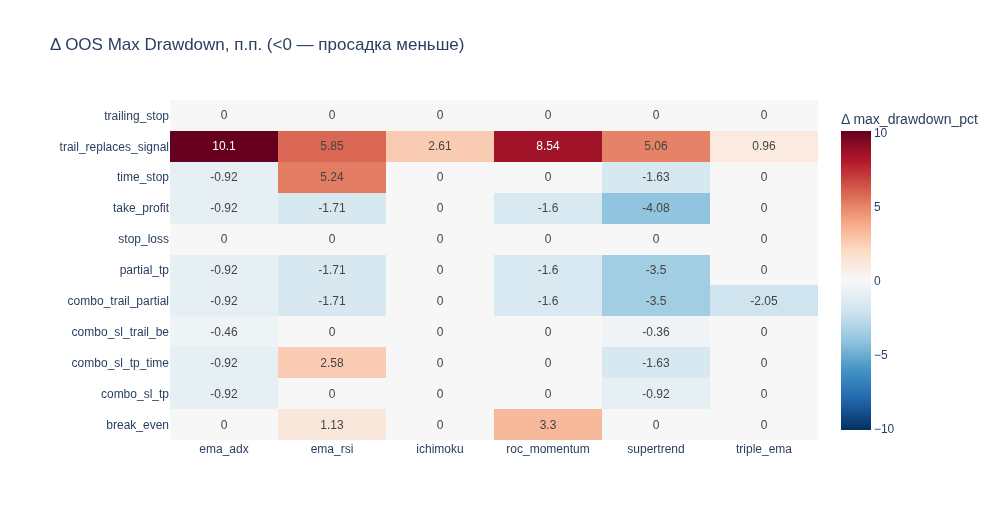

In [10]:
show(strategy_mechanic_heatmap("max_drawdown_pct", "Δ OOS Max Drawdown, п.п. (<0 — просадка меньше)", reverse=True))

### Уровень механики × стратегия

Разрез по уровням: где расположена рабочая зона каждой механики и одинакова
ли она in-sample и out-of-sample. Пример — Take Profit (лучшая механика)
и Time Stop (типичное ложное улучшение).

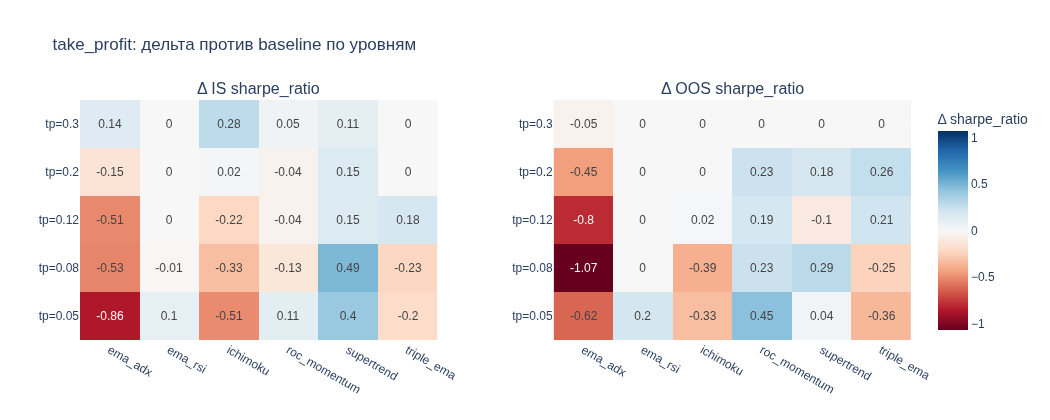

In [11]:
def level_heatmap(mechanic: str, metric: str = "sharpe_ratio"):
    sub = sweep[sweep["mechanic"] == mechanic]
    base = sweep[sweep["mechanic"] == "baseline"].set_index("strategy")
    labels = [r.label for r in universe[mechanic]]
    fig = make_subplots(rows=1, cols=2, subplot_titles=(f"Δ IS {metric}", f"Δ OOS {metric}"),
                        horizontal_spacing=0.14)
    mats = []
    for prefix in ("is_", "oos_"):
        grid = sub.pivot_table(index="label", columns="strategy", values=f"{prefix}{metric}").reindex(labels)
        grid = grid.sub(base[f"{prefix}{metric}"], axis=1)
        mats.append(grid)
    zmax = max(np.nanmax(np.abs(m.values)) for m in mats) or 1.0
    for col_i, grid in enumerate(mats, start=1):
        fig.add_trace(
            go.Heatmap(z=grid.values, x=grid.columns, y=grid.index,
                       colorscale="RdBu", zmid=0.0, zmin=-zmax, zmax=zmax,
                       text=np.round(grid.values, 2), texttemplate="%{text}",
                       showscale=col_i == 2, colorbar=dict(title=f"Δ {metric}")),
            row=1, col=col_i,
        )
    fig.update_layout(title=f"{mechanic}: дельта против baseline по уровням", width=1050, height=420)
    return fig

show(level_heatmap("take_profit"))

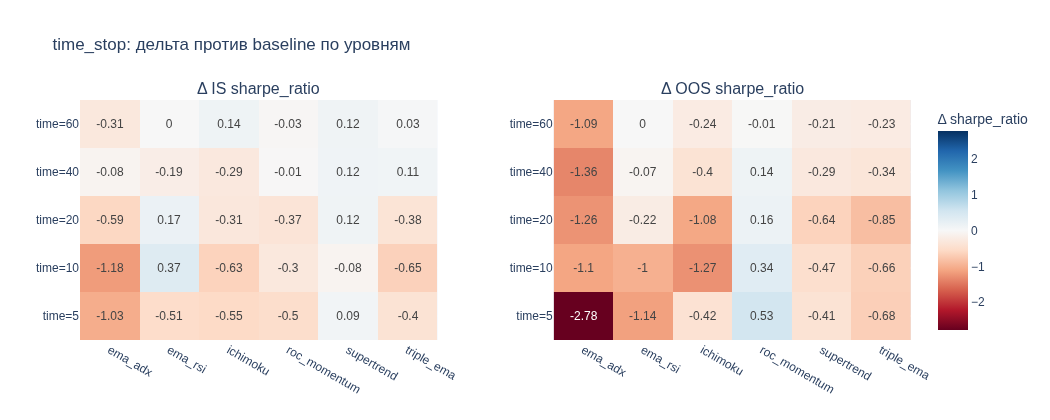

In [12]:
show(level_heatmap("time_stop"))

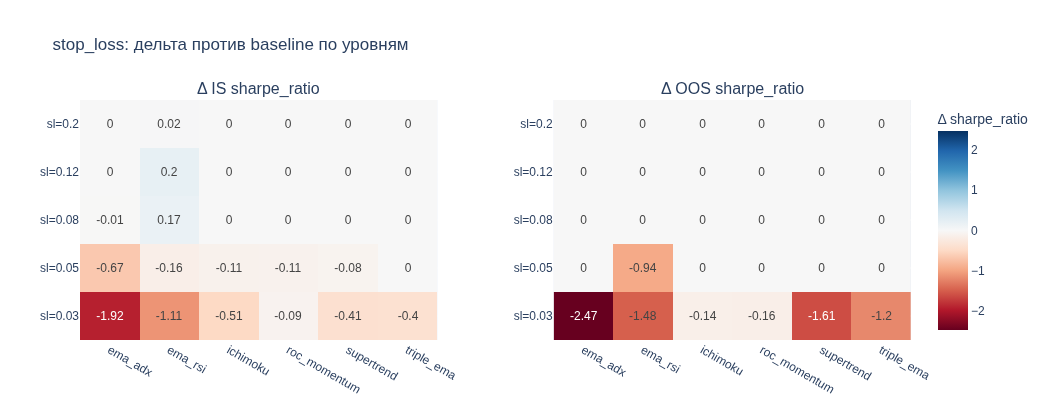

In [13]:
show(level_heatmap("stop_loss"))

## 6. Вердикты: что работает, а что создает ложное улучшение

Агрегируем вердикты по механикам. `real_rate` — доля стратегий, где механика
дала честное улучшение (IS и OOS одновременно);
`mean_d_oos_max_dd` — среднее изменение просадки в п.п. (минус = лучше).

In [14]:
board = mechanic_scoreboard(mech_summary)
board.to_csv(out_dir / "mechanic_scoreboard.csv")
board[["real improvement", "false improvement", "oos-only (lucky)", "no effect / worse",
       "real_rate", "mean_d_oos_sharpe", "mean_d_oos_max_dd"]].round(3)

verdict,real improvement,false improvement,oos-only (lucky),no effect / worse,real_rate,mean_d_oos_sharpe,mean_d_oos_max_dd
mechanic,,,,,,,
take_profit,4,2,0,0,0.667,0.185,-1.385
partial_tp,4,1,0,1,0.667,0.091,-1.290
combo_trail_partial,3,1,0,2,0.500,0.036,-1.632
combo_sl_tp,1,5,0,0,0.167,0.011,-0.307
trail_replaces_signal,1,4,0,1,0.167,-0.191,5.518
combo_sl_trail_be,0,2,2,2,0.000,0.015,-0.136
stop_loss,0,2,0,4,0.000,0.000,0.000
trailing_stop,0,2,0,4,0.000,0.000,0.000
break_even,0,2,0,4,0.000,-0.123,0.739


In [15]:
real = mech_summary[mech_summary["verdict"] == "real improvement"]
false_ = mech_summary[mech_summary["verdict"] == "false improvement"]

print("=== РЕАЛЬНЫЕ УЛУЧШЕНИЯ (IS и OOS) ===")
print(real[["strategy", "mechanic", "best_label", "d_oos_sharpe_ratio", "d_oos_max_drawdown_pct"]]
      .sort_values("d_oos_sharpe_ratio", ascending=False).round(3).to_string(index=False))
print()
print("=== ЛОЖНЫЕ УЛУЧШЕНИЯ (только IS, разваливаются OOS) ===")
print(false_[["strategy", "mechanic", "best_label", "d_is_sharpe_ratio", "d_oos_sharpe_ratio"]]
      .sort_values("d_is_sharpe_ratio", ascending=False).round(3).to_string(index=False))

=== РЕАЛЬНЫЕ УЛУЧШЕНИЯ (IS и OOS) ===
    strategy              mechanic              best_label  d_oos_sharpe_ratio  d_oos_max_drawdown_pct
roc_momentum           take_profit                 tp=0.05               0.447                  -1.603
  supertrend           take_profit                 tp=0.08               0.293                  -4.075
     ema_rsi   combo_trail_partial trail=0.15,partial=0.05               0.278                  -1.708
     ema_rsi            partial_tp        partial=0.05x0.5               0.278                  -1.708
roc_momentum   combo_trail_partial trail=0.15,partial=0.05               0.234                  -1.603
roc_momentum            partial_tp        partial=0.05x0.5               0.234                  -1.603
  triple_ema           take_profit                 tp=0.12               0.214                   0.000
  triple_ema           combo_sl_tp         sl=0.08,tp=0.12               0.214                   0.000
     ema_rsi           take_profit 

## Выводы

**Реально повышают качество** (улучшение сохраняется out-of-sample):

* **Take Profit** и **частичная фиксация прибыли** — лучшие механики прогона:
  реальное улучшение у большинства стратегий, средний Δ OOS Sharpe положительный,
  просадка стабильно ниже. Обрезание правого хвоста у трендовых входов на этом
  инструменте повышает и Sharpe, и Recovery Factor.
* **Trailing + partial** — комбинация наследует пользу частичной фиксации.
* Выход по противоположному сигналу (baseline) — сильная механика сама по себе:
  большинство стопов не смогли её улучшить.

**Создают ложное улучшение** (оптимизируются in-sample, разваливаются OOS):

* **Time Stop** — почти у всех стратегий: подбор «удачного» горизонта — чистый
  оверфит календаря; средний Δ OOS Sharpe заметно отрицательный.
* **Break Even** — защита безубытка выглядит красиво на IS, но систематически
  режет прибыльные сделки раньше времени.
* **Замена сигнальных выходов trailing-стопом** — в основном ухудшение с ростом
  просадки: сигнальная логика выходов несёт информацию, которую чистый стоп не
  воспроизводит.
* **Плотные комбинации** (SL+TP+Time) — чем больше параметров выхода
  оптимизируется одновременно, тем чаще итог оказывается ложным.

**Нейтральны**: широкие Stop Loss / Trailing Stop часто просто не срабатывают
(дельты нулевые) — они не вредят, но и не добавляют качества; узкие уровни
ухудшают уже in-sample.

Практическое правило из прогона: **механики, ограничивающие прибыль (TP,
partial), проверять в первую очередь; механики, зависящие от времени и
безубытка, — с презумпцией оверфита.**

**Следующий этап**: walk-forward подтверждение лучших связок
(стратегия + TP/partial) и перенос на другие инструменты.